In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [29]:
# -----------------------------
# 1. Load data
# -----------------------------
PROJECT_ROOT = Path().resolve().parent
data_path = PROJECT_ROOT / "data" / "processed" / "iberia.csv"

df_pt = pd.read_csv(
    data_path,
    parse_dates=["DateUTC"]
)

# Keep only needed columns
df_ib = df_pt[["DateUTC", "Value"]].copy()

# Sort by time
df_ib = df_ib.sort_values("DateUTC")

# Aggregate duplicate timestamps if needed
df_ib = (
    df_ib.groupby("DateUTC", as_index=True)["Value"]
    .mean()
    .to_frame()
)

# Enforce hourly frequency
df_ib = df_ib.asfreq("h")

# Fill missing values if any
df_ib["Value"] = df_ib["Value"].interpolate(method="time")

In [61]:
# -----------------------------
# 2. Train / test split
# -----------------------------
# Last 7 days for testing
# Ensure sorted
df_ib = df_ib.sort_index()

# Split by date
train = df_ib.loc[: "2025-07-31"]
test  = df_ib.loc["2025-08-01":]

In [62]:
# -----------------------------
# 3. Fit Holt-Winters model
# -----------------------------
# Since trend is weak, use trend=None
# Since daily seasonality is strong, use seasonal_periods=24
model = ExponentialSmoothing(
    train["Value"],
    trend=None,
    seasonal="add",
    seasonal_periods=24
)

fit = model.fit(optimized=True)

In [63]:
# -----------------------------
# 4. Forecast next 24 hours
# -----------------------------
forecast_steps = 24

actual_24h = test["Value"].iloc[:forecast_steps]
forecast_24h = pd.Series(forecast_24h.values, index=actual_24h.index)


In [64]:
# -----------------------------
# 5. Evaluate forecast
# -----------------------------
mae = mean_absolute_error(actual_24h, forecast_24h)
rmse = np.sqrt(mean_squared_error(actual_24h, forecast_24h))
mape = np.mean(np.abs((actual_24h - forecast_24h) / actual_24h)) * 100

print(f"24h Forecast MAE:  {mae:.2f}")
print(f"24h Forecast RMSE: {rmse:.2f}")
print(f"24h Forecast MAPE: {mape:.2f}%")

24h Forecast MAE:  1232.97
24h Forecast RMSE: 1298.20
24h Forecast MAPE: 7.24%


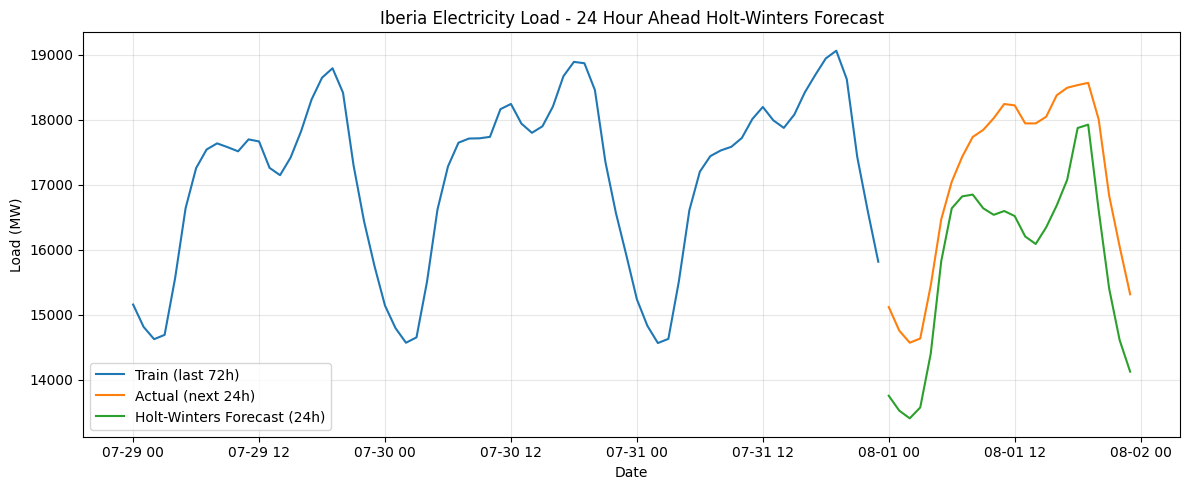

In [67]:
# -----------------------------
# 6. Plot 24h forecast
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    train.index[-72:],
    train["Value"].iloc[-72:],
    label="Train (last 72h)"
)

plt.plot(
    actual_24h.index,
    actual_24h,
    label="Actual (next 24h)"
)

plt.plot(
    actual_24h.index,
    forecast_24h,
    label="Holt-Winters Forecast (24h)"
)

plt.title("Iberia Electricity Load - 24 Hour Ahead Holt-Winters Forecast")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/holt_winters_forecast.png", dpi=300)
plt.show()

Full Test MAE:  1233.00
Full Test RMSE: 1508.43
Full Test MAPE: 7.43%


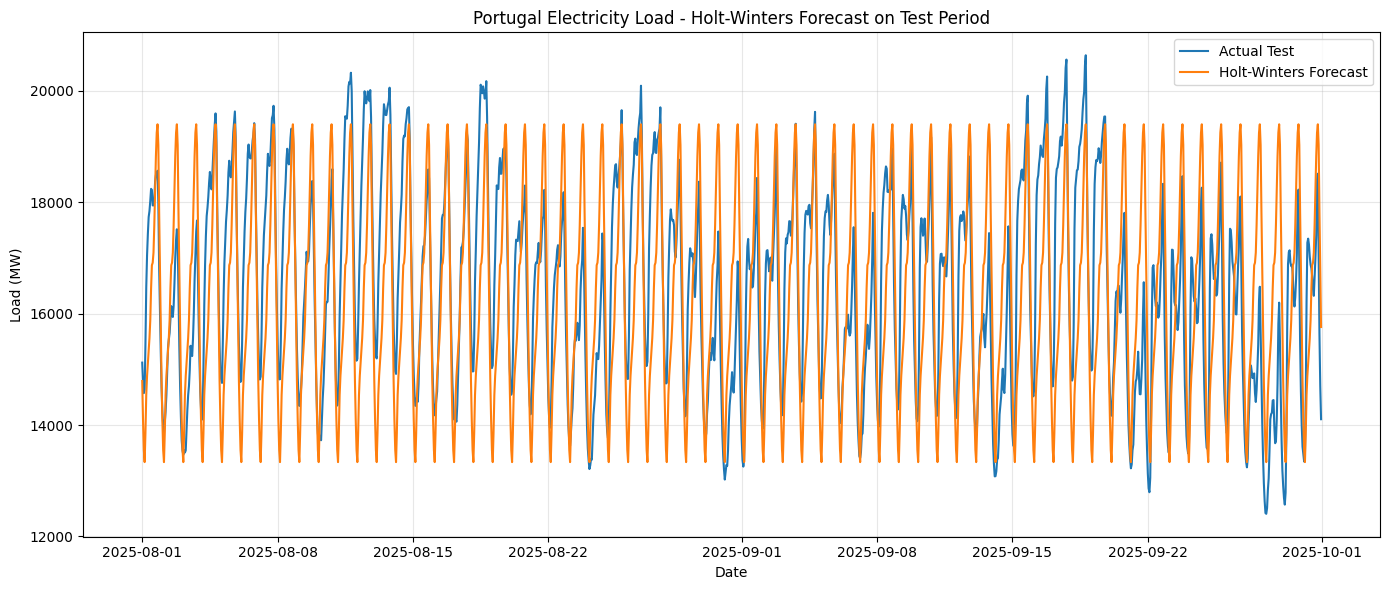

In [66]:
# -----------------------------
# 7. Forecast full test period
# -----------------------------
full_forecast = fit.forecast(len(test))

full_mae = mean_absolute_error(test["Value"], full_forecast)
full_rmse = np.sqrt(mean_squared_error(test["Value"], full_forecast))
full_mape = np.mean(np.abs((test["Value"] - full_forecast) / test["Value"])) * 100

print(f"Full Test MAE:  {full_mae:.2f}")
print(f"Full Test RMSE: {full_rmse:.2f}")
print(f"Full Test MAPE: {full_mape:.2f}%")

plt.figure(figsize=(14, 6))
plt.plot(test.index, test["Value"], label="Actual Test")
plt.plot(test.index, full_forecast, label="Holt-Winters Forecast")
plt.title("Portugal Electricity Load - Holt-Winters Forecast on Test Period")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()